In [1]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

# Compose transformations
train_transforms = transforms.Compose([transforms.ToTensor(), transforms.Resize((128, 128)),
])

# Create Dataset using ImageFolder
dataset_train = ImageFolder("clouds_train", transform=train_transforms)

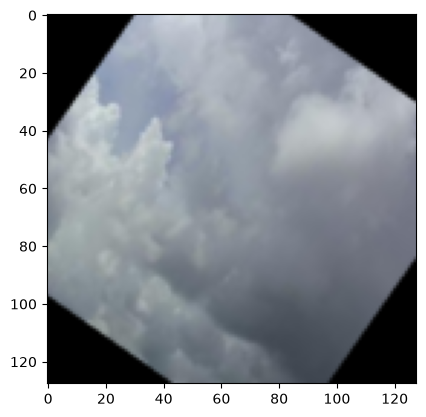

In [2]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

train_transforms = transforms.Compose([
# Add horizontal flip and rotation
	transforms.RandomHorizontalFlip(),
	transforms.RandomRotation(45),
	transforms.ToTensor(),
	transforms.Resize((128, 128)),
])

dataset_train = ImageFolder("clouds_train",transform=train_transforms)
dataloader_train = DataLoader(dataset_train, shuffle=True, batch_size=1)
image, label = next(iter(dataloader_train))

# Reshape the image tensor
image = image.squeeze().permute(1, 2, 0)

# Display the image
plt.imshow(image)
plt.show()

## Convolutional layer

In [3]:
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
        )
        self.classifier = nn.Linear(64*32*32, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

## Training the network

In [4]:
num_classes = len(dataset_train.classes)
net = Net(num_classes)

dataloader_train = DataLoader(dataset_train, shuffle=True, batch_size=16)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)

num_epochs = 3
net.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(dataloader_train):.4f}")

Epoch 1/3, Loss: 2.3954
Epoch 2/3, Loss: 1.4819
Epoch 3/3, Loss: 1.3674


## Test set

In [5]:
test_transforms = transforms.Compose([
	transforms.ToTensor(),
	transforms.Resize((128, 128)),
])

dataset_test = ImageFolder("clouds_test", transform=test_transforms)
dataloader_test = DataLoader(dataset_test, shuffle=False, batch_size=16)

In [6]:
from torchmetrics import Recall

recall_per_class = Recall(task="multiclass", num_classes=7, average=None)
recall_micro = Recall(task="multiclass", num_classes=7, average="micro")
recall_macro = Recall(task="multiclass", num_classes=7, average="macro")
recall_weighted = Recall(task="multiclass", num_classes=7, average="weighted")

In [7]:
from torchmetrics import Precision, Recall

metric_precision = Precision(
    task="multiclass", num_classes=7, average="macro"
)
metric_recall = Recall(
    task="multiclass", num_classes=7, average="macro"
)
net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)
precision = metric_precision.compute()
recall = metric_recall.compute()

print(f"Precision: {precision}")
print(f"Recall: {recall}")

Precision: 0.6611618995666504
Recall: 0.5781180262565613


In [8]:
metric_recall = Recall(
    task="multiclass", num_classes=7, average=None
)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_recall(preds, labels)
recall = metric_recall.compute()

print(recall)

tensor([0.1818, 0.8125, 0.4545, 0.6000, 0.4951, 0.7000, 0.8028])


In [9]:
dataset_test.class_to_idx

{'cirriform clouds': 0,
 'clear sky': 1,
 'cumulonimbus clouds': 2,
 'cumulus clouds': 3,
 'high cumuliform clouds': 4,
 'stratiform clouds': 5,
 'stratocumulus clouds': 6}

In [10]:
dataset_test.class_to_idx
{
  k: recall[v].item()
  for k, v
  in dataset_test.class_to_idx.items()
}

{'cirriform clouds': 0.1818181872367859,
 'clear sky': 0.8125,
 'cumulonimbus clouds': 0.4545454680919647,
 'cumulus clouds': 0.6000000238418579,
 'high cumuliform clouds': 0.49514561891555786,
 'stratiform clouds': 0.699999988079071,
 'stratocumulus clouds': 0.8028169274330139}